In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from google.colab import drive

# 1. Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- CONFIGURATION ---
DATA_PATH = '/content/drive/MyDrive/InstruNet_project/Processed_Data'
IMG_HEIGHT = 128  # Standard Mel-spectrogram height
IMG_WIDTH = 173   # Standard width for ~4 seconds

X = []
y = []

# 2. Load Data Loop
for instrument in os.listdir(DATA_PATH):
    folder_path = os.path.join(DATA_PATH, instrument)

    # Ensure it's a folder
    if os.path.isdir(folder_path):
        print(f"   -> Processing: {instrument}")

        for file in os.listdir(folder_path):
            if file.endswith('.npy'):
                try:
                    # Load file
                    file_path = os.path.join(folder_path, file)
                    data = np.load(file_path)

                    # FORCE SHAPE FIX: Ensure all images are exactly (128, 173)
                    if data.shape[1] > IMG_WIDTH:
                        data = data[:, :IMG_WIDTH] # Crop
                    elif data.shape[1] < IMG_WIDTH:
                        padding = IMG_WIDTH - data.shape[1]
                        data = np.pad(data, ((0,0), (0, padding))) # Pad with zeros

                    X.append(data)
                    y.append(instrument)
                except Exception as e:
                    pass

# 3. Convert to Arrays
X = np.array(X)
y = np.array(y)

# 4. Prepare for CNN (Add Channel Dimension)
# CNNs need input shape: (Height, Width, Channel) -> (128, 173, 1)
X = X[..., np.newaxis]

# 5. Encode Labels (Guitar -> 0, Flute -> 1)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
class_names = encoder.classes_

# 6. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"\n Data Ready! Training on {len(X_train)} samples, Testing on {len(X_test)} samples.")

   -> Processing: bass
   -> Processing: keyboard
   -> Processing: guitar
   -> Processing: reed
   -> Processing: flute
   -> Processing: string
   -> Processing: vocal
   -> Processing: brass
   -> Processing: mallet
   -> Processing: organ

 Data Ready! Training on 3276 samples, Testing on 820 samples.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/35
103/103 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - accuracy: 0.3592 - loss: 2.0052 - val_accuracy: 0.3451 - val_loss: 1.9754
Epoch 2/35
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7948 - loss: 0.6061 - val_accuracy: 0.7390 - val_loss: 0.7556
Epoch 3/35
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9201 - loss: 0.2786 - val_accuracy: 0.8915 - val_loss: 0.3263
Epoch 4/35
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9503 - loss: 0.1444 - val_accuracy: 0.9634 - val_loss: 0.1435
Epoch 5/35
103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9687 - loss: 0.0970 - val_accuracy: 0.9732 - val_loss: 0.0864
Epoch 6/35
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9794 - loss: 0.0620 - val_accuracy: 0.9768 - val_loss: 0.0880
Epoch 7/35
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9841 - loss: 0.0564 - val_accuracy: 0.9890 - val_loss: 0.0433
Epoch 8/35
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9858 - loss: 0.0479 - val_acc

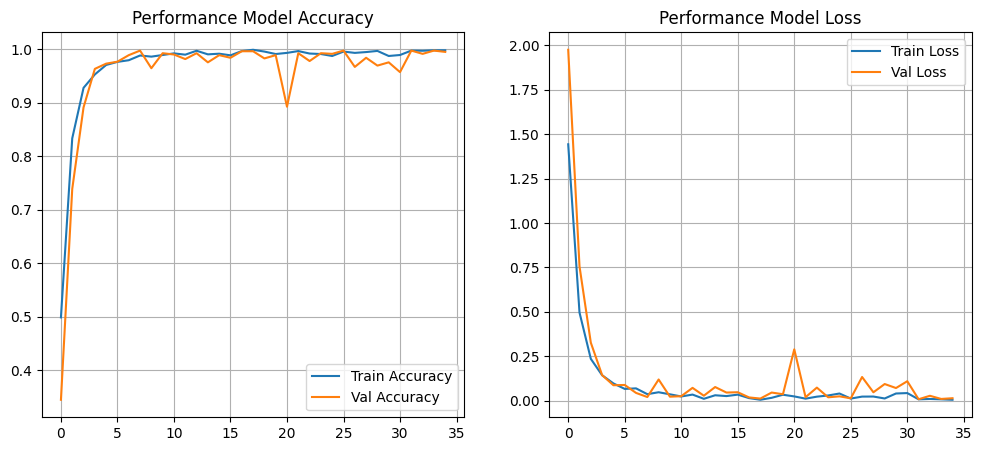

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# Ensure these match your previous setup
IMG_HEIGHT = 128
IMG_WIDTH = 173
num_classes = len(class_names) # Should be around 10

# --- THE "HIGH PERFORMANCE" MODEL ---
model_perf = models.Sequential([
    # Block 1: The Basics
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(), # Keeps learning stable

    # Block 2: The Details
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    # Block 3: The Shapes
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2), # Light restriction only

    # Block 4: The Complex Features (New Layer for extra power)
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Flatten(),

    # Dense Block: The Decision Maker
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3), # Moderate restriction here

    # Output
    layers.Dense(num_classes, activation='softmax')
])

# Compile with a slightly lower learning rate for precision
model_perf.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Train for longer to ensure we hit the peak
history_perf = model_perf.fit(X_train, y_train,
                              epochs=35,
                              validation_data=(X_test, y_test),
                              batch_size=32)

# --- PLOT THE RESULTS ---
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_perf.history['accuracy'], label='Train Accuracy')
plt.plot(history_perf.history['val_accuracy'], label='Val Accuracy')
plt.title('Performance Model Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_perf.history['loss'], label='Train Loss')
plt.plot(history_perf.history['val_loss'], label='Val Loss')
plt.title('Performance Model Loss')
plt.legend()
plt.grid(True)

plt.show()

# Save this one as the final choice
model_perf.save('/content/drive/MyDrive/InstruNet_project/instrunet_best_model.h5')

Evaluating Model on Test Data...
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


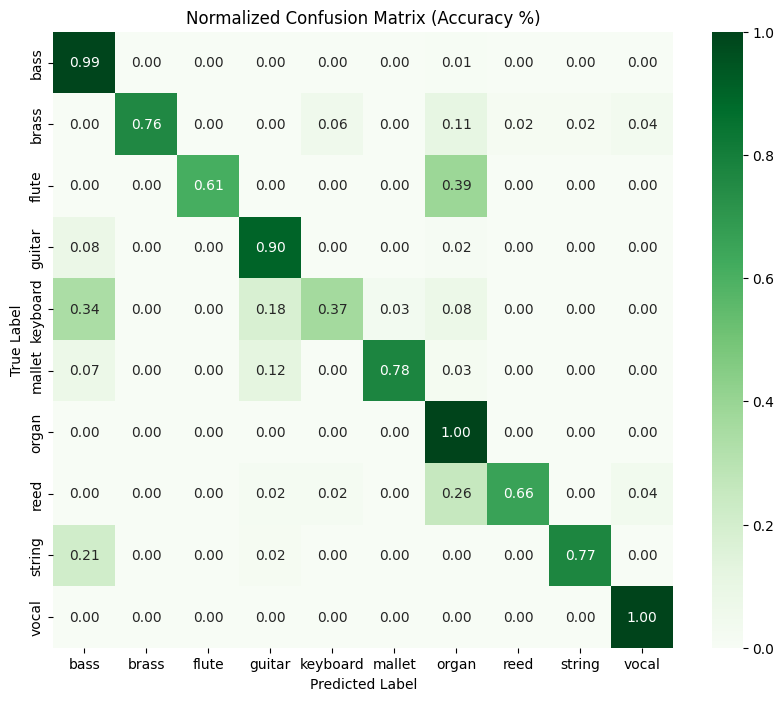


Classification Report:

              precision    recall  f1-score   support

        bass       0.68      0.99      0.81       169
       brass       1.00      0.76      0.86        54
       flute       1.00      0.61      0.76        36
      guitar       0.77      0.90      0.83       131
    keyboard       0.93      0.37      0.53       153
      mallet       0.86      0.78      0.82        40
       organ       0.68      1.00      0.81       101
        reed       0.97      0.66      0.78        47
      string       0.98      0.77      0.86        61
       vocal       0.88      1.00      0.93        28

    accuracy                           0.78       820
   macro avg       0.87      0.78      0.80       820
weighted avg       0.83      0.78      0.77       820


Success! Model saved to: /content/drive/MyDrive/InstruNet_project/instrunet_best_model.h5


In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Get Predictions
print("Evaluating Model on Test Data...")
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Generate NORMALIZED Confusion Matrix (Deliverable #2)
# We normalize over the 'true' conditions (rows) to show percentages
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix (Accuracy %)')
plt.show()

# 3. Text Report (Deliverable #3)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# 4. Save the Model
save_path = '/content/drive/MyDrive/InstruNet_project/instrunet_best_model.h5'
model.save(save_path)
print(f"\nSuccess! Model saved to: {save_path}")